In [1]:
   import os
   os.environ["CUDA_VISIBLE_DEVICES"] = "0"   # use one GPU only

In [2]:
# --- Cell 1: install ---
!pip install -q transformers datasets accelerate arabert farasapy

# --- Cell 2: data + preprocessing ---
import torch
print(torch.cuda.device_count())
import pandas as pd
from datasets import load_dataset
from arabert.preprocess import ArabertPreprocessor

model_name = "aubmindlab/bert-base-arabertv02-twitter"
dataset = load_dataset("Abdelrahman-Rezk/Arabic_Dialect_Identification")
train_df = dataset['train'].to_pandas()
val_df = dataset['validation'].to_pandas()
test_df = dataset['test'].to_pandas()

arabert_prep = ArabertPreprocessor(model_name=model_name)
for d in (train_df, val_df, test_df):
    d['text_clean'] = d['text'].apply(arabert_prep.preprocess)

train_df = train_df[train_df['text_clean'].str.strip() != ''].reset_index(drop=True)
print(len(train_df), len(val_df), len(test_df))   # expect 440021 9164 8981

# --- Cell 3: tokenize + datasets + metric ---
from transformers import AutoTokenizer
from sklearn.metrics import f1_score

tokenizer = AutoTokenizer.from_pretrained(model_name)
enc = lambda df: tokenizer(list(df['text_clean']), truncation=True, padding=True, max_length=64)
train_encodings, val_encodings, test_encodings = enc(train_df), enc(val_df), enc(test_df)

class DialectDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item
    def __len__(self):
        return len(self.labels)

def compute_metrics(pred):
    return {"macro_f1": f1_score(pred.label_ids, pred.predictions.argmax(-1), average='macro')}

train_dataset = DialectDataset(train_encodings, list(train_df['label']))
val_dataset = DialectDataset(val_encodings, list(val_df['label']))
test_dataset = DialectDataset(test_encodings, list(test_df['label']))

# --- Cell 4: train + save ---
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=18)

n_gpu = max(torch.cuda.device_count(), 1)
args = TrainingArguments(
    output_dir="/kaggle/working/results_twitter",
    num_train_epochs=4,
    per_device_train_batch_size=32 // n_gpu,   # keeps the total batch at 32, same as before
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    fp16=True,
    logging_steps=500,
    report_to="none",                          # stops Kaggle asking for a wandb login
)

trainer = Trainer(model=model, args=args, train_dataset=train_dataset,
                  eval_dataset=val_dataset, compute_metrics=compute_metrics)
trainer.train()

trainer.save_model("/kaggle/working/final_model")
tokenizer.save_pretrained("/kaggle/working/final_model")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.0/185.0 kB 3.8 MB/s eta 0:00:0000:01
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 5.8 MB/s eta 0:00:00
1


/usr/local/lib/python3.13/dist-packages/pyarabic/araby.py:274: SyntaxWarning: invalid escape sequence '\w'
  TOKEN_PATTERN = re.compile(u"([^\w\u0670\u064b-\u0652']+)", re.UNICODE)
/usr/local/lib/python3.13/dist-packages/pyarabic/araby.py:276: SyntaxWarning: invalid escape sequence '\w'
  TOKEN_PATTERN_SPLIT = re.compile(u"([\w\u0670\u064b-\u0652']+)", re.UNICODE)
/usr/local/lib/python3.13/dist-packages/pyarabic/araby.py:281: SyntaxWarning: invalid escape sequence '\s'
  ARABIC_STRING = re.compile(u"([^\u0600-\u0652%s%s%s\s\d])" \
/usr/local/lib/python3.13/dist-packages/pyarabic/araby.py:1237: SyntaxWarning: invalid escape sequence '\s'
  u"(?<=\s(%s|%s))%s" % (WAW, YEH, FATHA), \
/usr/local/lib/python3.13/dist-packages/pyarabic/araby.py:1450: SyntaxWarning: invalid escape sequence '\s'
  text = re.sub(u"(?<=[\s\d])([%s])+"%(TASHKEEL_STRING),"",text,  re.UNICODE)


README.md:   0%|          | 0.00/4.94k [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


dataset_infos.json:   0%|          | 0.00/1.09k [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/kaggle/working/final_model/tokenizer_config.json',
 '/kaggle/working/final_model/tokenizer.json')

In [4]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

label_names = ['OM', 'SD', 'SA', 'KW', 'QA', 'LB', 'JO', 'SY', 'IQ', 'MA', 'EG', 'PL', 'YE', 'BH', 'DZ', 'AE', 'TN', 'LY']

out = trainer.predict(test_dataset)
preds = out.predictions.argmax(-1)
y_true = out.label_ids

print(out.metrics)   # test_macro_f1 is your headline number
print(classification_report(y_true, preds, target_names=label_names, digits=3))

{'test_loss': 1.1349657773971558, 'test_macro_f1': 0.6309816954442772, 'test_runtime': 10.2083, 'test_samples_per_second': 879.777, 'test_steps_per_second': 13.812}
              precision    recall  f1-score   support

          OM      0.523     0.507     0.515       375
          SD      0.772     0.622     0.689       283
          SA      0.531     0.578     0.554       526
          KW      0.674     0.657     0.665       825
          QA      0.576     0.596     0.586       609
          LB      0.758     0.754     0.756       541
          JO      0.532     0.528     0.530       547
          SY      0.589     0.528     0.557       318
          IQ      0.699     0.595     0.643       304
          MA      0.789     0.646     0.710       226
          EG      0.816     0.901     0.856      1130
          PL      0.615     0.676     0.644       857
          YE      0.535     0.395     0.454       195
          BH      0.502     0.493     0.498       515
          DZ      0.699 

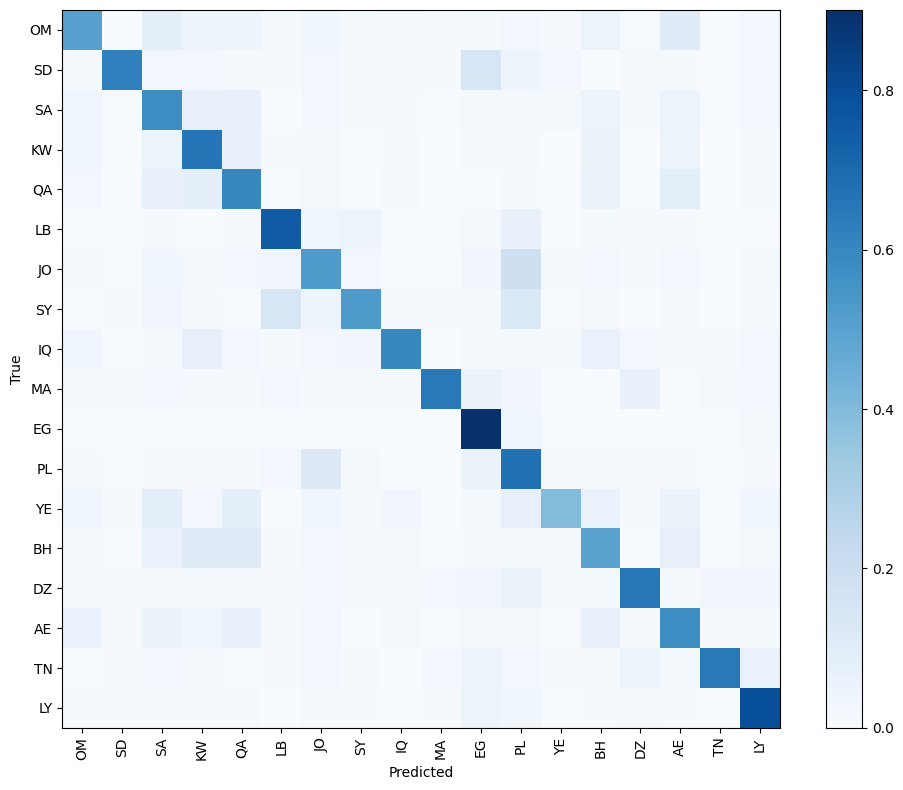

JO predicted as PL: 104 tweets
PL predicted as JO: 99 tweets
BH predicted as KW: 57 tweets
BH predicted as QA: 56 tweets
KW predicted as QA: 55 tweets
QA predicted as AE: 52 tweets
QA predicted as KW: 51 tweets
PL predicted as EG: 49 tweets
KW predicted as BH: 48 tweets
SY predicted as LB: 45 tweets


In [5]:
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, preds, normalize='true')
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(18)); ax.set_xticklabels(label_names, rotation=90)
ax.set_yticks(range(18)); ax.set_yticklabels(label_names)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.colorbar(im)
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150)
plt.show()

cm_raw = confusion_matrix(y_true, preds)
np.fill_diagonal(cm_raw, 0)
top = np.dstack(np.unravel_index(np.argsort(-cm_raw.ravel())[:10], cm_raw.shape))[0]
for i, j in top:
    print(f"{label_names[i]} predicted as {label_names[j]}: {cm_raw[i, j]} tweets")

In [6]:
import shutil, os
print(os.listdir('/kaggle/working/final_model'))   # check the model files are there
shutil.make_archive('/kaggle/working/final_model', 'zip', '/kaggle/working/final_model')

['tokenizer_config.json', 'config.json', 'model.safetensors', 'training_args.bin', 'tokenizer.json']


'/kaggle/working/final_model.zip'

In [7]:
region = {'OM':'Gulf','SA':'Gulf','KW':'Gulf','QA':'Gulf','BH':'Gulf','AE':'Gulf','YE':'Gulf',
          'LB':'Levant','JO':'Levant','SY':'Levant','PL':'Levant',
          'EG':'Nile','SD':'Nile','IQ':'Iraq',
          'MA':'Maghreb','DZ':'Maghreb','TN':'Maghreb','LY':'Maghreb'}

true_r = np.array([region[label_names[i]] for i in y_true])
pred_r = np.array([region[label_names[i]] for i in preds])
print("Region accuracy:", round((true_r == pred_r).mean(), 3))
print("Region macro F1:", round(f1_score(true_r, pred_r, average='macro'), 3))

Region accuracy: 0.846
Region macro F1: 0.805


In [8]:
print(classification_report(true_r, pred_r, digits=3))

ev = test_df.copy()
ev['true'] = [label_names[i] for i in y_true]
ev['pred'] = [label_names[i] for i in preds]
ev.to_csv('/kaggle/working/test_predictions.csv', index=False)

              precision    recall  f1-score   support

        Gulf      0.879     0.884     0.881      3561
        Iraq      0.699     0.595     0.643       304
      Levant      0.821     0.838     0.830      2263
     Maghreb      0.839     0.789     0.813      1440
        Nile      0.840     0.878     0.858      1413

    accuracy                          0.846      8981
   macro avg      0.816     0.797     0.805      8981
weighted avg      0.846     0.846     0.846      8981



In [9]:
# where do the Iraqi tweets go?
print(ev[ev['true'] == 'IQ']['pred'].value_counts().head(6))

# which tweets get wrongly called Iraqi?
print(ev[ev['pred'] == 'IQ']['true'].value_counts().head(6))

# how many training tweets does each country have?
train_names = train_df['label'].map(lambda i: label_names[i])
print(train_names.value_counts())

pred
IQ    181
KW     22
BH     19
OM     11
SY      9
QA      8
Name: count, dtype: int64
true
IQ    181
BH      9
KW      9
AE      8
QA      7
OM      7
Name: count, dtype: int64
label
EG    55352
PL    42008
KW    40440
LY    35051
QA    29838
JO    26813
LB    26524
SA    25769
AE    25253
BH    25251
OM    18357
SY    15598
DZ    15542
IQ    14883
SD    13847
MA    11082
YE     9533
TN     8880
Name: count, dtype: int64


In [10]:
import os
print(os.path.getsize('/kaggle/working/test_predictions.csv') / 1e6, "MB")

2.958749 MB


In [11]:
import os
from IPython.display import FileLink
os.chdir('/kaggle/working')
FileLink('test_predictions.csv')

/kaggle/working/test_predictions.csv